In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load and clean data (repeating our cleaning steps)
df = pd.read_csv('../data/train.csv')

# Fill missing values
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']
for col in none_cols:
    df[col] = df[col].fillna('None')

zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
             'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']
for col in zero_cols:
    df[col] = df[col].fillna(0)

df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median()))
df = df.dropna(subset=['Electrical'])

# Prepare features
X = pd.get_dummies(df.drop(['SalePrice', 'Id'], axis=1))
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data ready for modeling!")
print(f"Training: {X_train.shape} | Testing: {X_test.shape}")

Data ready for modeling!
Training: (1167, 302) | Testing: (292, 302)


In [3]:
# Build Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
lr_predictions = lr_model.predict(X_test)

# Evaluate the model
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Results:")
print(f"RMSE: ${lr_rmse:,.0f}")
print(f"R² Score: {lr_r2:.4f}")

Linear Regression Results:
RMSE: $88,386
R² Score: -0.4462


In [4]:
# Build Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
rf_predictions = rf_model.predict(X_test)

# Evaluate the model
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results:")
print(f"RMSE: ${rf_rmse:,.0f}")
print(f"R² Score: {rf_r2:.4f}")

Random Forest Results:
RMSE: $24,462
R² Score: 0.8892


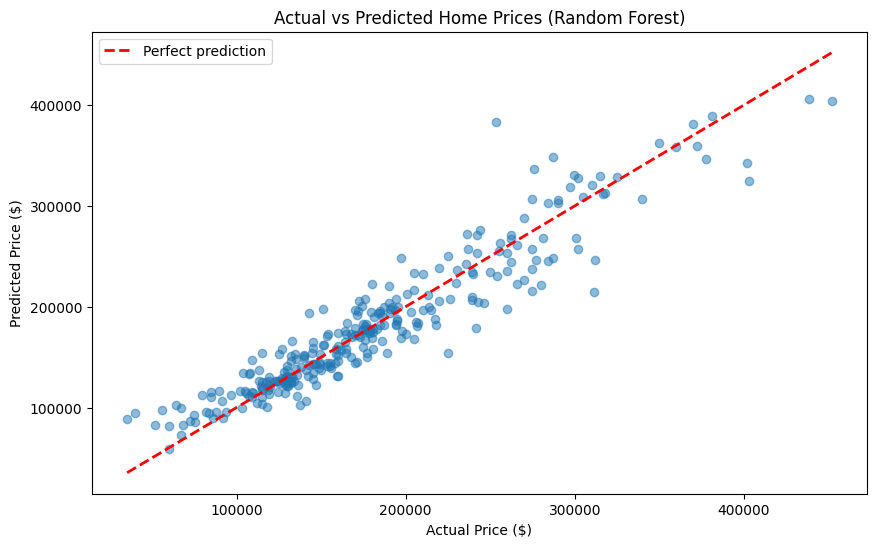

In [6]:
import matplotlib.pyplot as plt

# Plot actual vs predicted prices
plt.figure(figsize=(10, 6))
plt.scatter(y_test, rf_predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Actual vs Predicted Home Prices (Random Forest)')
plt.legend()
plt.savefig('../visuals/actual_vs_predicted.png')
plt.show()